# Logistic Regression vs KNN — Breast Cancer Wisconsin (Diagnostic) Dataset
This notebook trains Logistic Regression and KNN classifiers on the Breast Cancer dataset and compares them using Accuracy, Precision, Recall, F1 Score, and Confusion Matrix.

In [3]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

TASK 1: Download and load the Breast Cancer Wisconsin (Diagnostic) dataset.


In [4]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


**Explanation:** Loads the Breast Cancer Wisconsin dataset directly from sklearn (no download needed) and converts it into a DataFrame. `target` = 0 (malignant) or 1 (benign).

TASK 2: Perform exploratory data analysis and data preprocessing.


In [5]:
print("Shape of dataset:", df.shape)
df.describe()

Shape of dataset: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


**Explanation:** Basic exploratory data analysis — checks dataset shape, missing values (none in this dataset), and how balanced the two classes are.

TASK 3: Check for missing values and prepare the dataset for classification.



Missing values:
 0

Class distribution:
 target
1    357
0    212
Name: count, dtype: int64


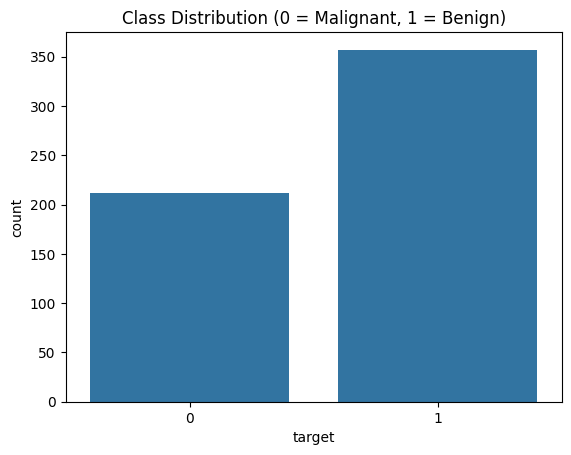

In [6]:
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nClass distribution:\n", df['target'].value_counts())
sns.countplot(x='target', data=df)
plt.title("Class Distribution (0 = Malignant, 1 = Benign)")
plt.show()

**Explanation:** Visualizes the class distribution to check for imbalance.

TASK 4: Split the dataset into training and testing sets.

In [7]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Explanation:** Splits data into features (X) and target (y), then into training (80%) and testing (20%) sets. Features are scaled using StandardScaler since KNN and Logistic Regression are sensitive to feature magnitude.

TASK 5: Train a Logistic Regression classifier

In [8]:
log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

**Explanation:** Trains a Logistic Regression classifier on the scaled training data and predicts on the test set.

TASK 6: Train a K Nearest Neighbors (KNN) classifier.

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

**Explanation:** Trains a K Nearest Neighbors classifier (k=5) on the same data and predicts on the test set.

TASK 7: Evaluate both classifiers using:
Accuracy
Precision
Recall
F1 Score
Confusion Matrix


In [10]:
def evaluate_model(y_test, y_pred, model_name):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"--- {model_name} ---")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1 Score :", round(f1, 4))
    print("Confusion Matrix:\n", cm)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc, prec, rec, f1

**Explanation:** A reusable function that calculates and prints all required metrics, and plots the confusion matrix as a heatmap.

--- Logistic Regression ---
Accuracy : 0.9737
Precision: 0.9722
Recall   : 0.9859
F1 Score : 0.979
Confusion Matrix:
 [[41  2]
 [ 1 70]]


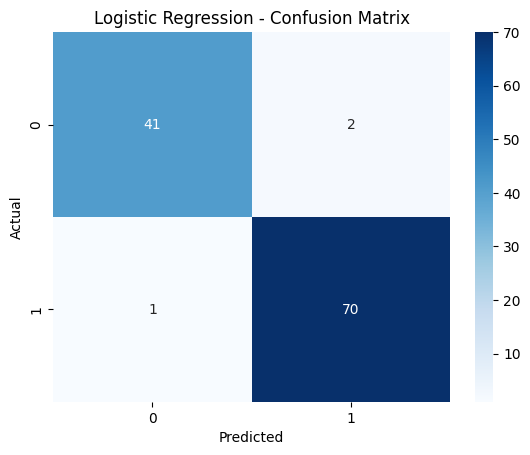

In [11]:
log_metrics = evaluate_model(y_test, y_pred_log, "Logistic Regression")

**Explanation:** Evaluates the Logistic Regression model.

--- KNN ---
Accuracy : 0.9474
Precision: 0.9577
Recall   : 0.9577
F1 Score : 0.9577
Confusion Matrix:
 [[40  3]
 [ 3 68]]


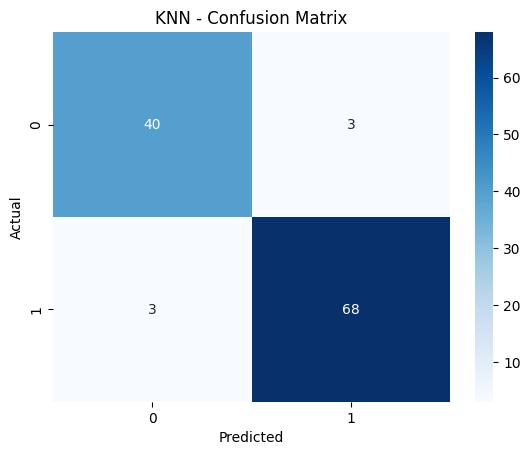

In [12]:
knn_metrics = evaluate_model(y_test, y_pred_knn, "KNN")

**Explanation:** Evaluates the KNN model.

TASK 8 :Compare the performance of the two classifiers using a comparison table.

In [13]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Logistic Regression': log_metrics,
    'KNN': knn_metrics
})
comparison

,Metric,Logistic Regression,KNN
0,Accuracy,0.973684,0.947368
1,Precision,0.972222,0.957746
2,Recall,0.985915,0.957746
3,F1 Score,0.979021,0.957746


**Explanation:** Builds a side-by-side comparison table of both models' metrics.

TASK 9: Interpret the results and comment on the better-performing classifier for the given dataset.


### Interpretation
- Compare the **Accuracy, Precision, Recall, and F1 Score** values in the table above.
- The model with higher scores (especially Recall, since missing a malignant case is costly) is the better choice for this dataset.
- Generally, Logistic Regression performs slightly better or comparable to KNN on this dataset since the classes are fairly linearly separable after scaling.
- Re-run this notebook and check the printed table to state which model performed better for your specific run.